# Theme 6: Predictive Pricing & Strategy (Machine Learning)

**Objective 11: Predict the "Fair Market Price" of a laptop based on its hardware specifications using a Regression model.**

**Goal & Purpose:**
The goal is to build an AI model that learns how much a laptop *should* cost based on its specs (RAM, CPU, GPU, Weight, etc.). As a Retail Consultant, we use this to evaluate a store's pricing strategy automatically. 

**Intuitive Example:**
* **Scenario A:** A store is selling an Asus laptop for **25,000,000 VND**. Our model looks at its specs and predicts it should cost **20,000,000 VND**. 
  * **Conclusion:** It is selling too expensive.
  * **Action:** Recommend the store to apply a discount voucher to clear inventory.
* **Scenario B:** A store is selling a Lenovo laptop for **15,000,000 VND**. Our model predicts it should cost **19,000,000 VND**.
  * **Conclusion:** It is a bargain. 
  * **Action:** Put a "Best Deal" badge on it and run Facebook Ads to attract buyers.

**Assumptions & Limitations:**
* **Assumption:** The hardware market is currently stable.
* **Limitation:** If there is a sudden global crisis (like a factory fire causing RAM prices to triple), the model's predictions will be wrong. The model must be retrained monthly with fresh data to stay accurate.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set display options for better readability
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

### Step 1: Load Data and Prevent Data Leakage
We load the data and drop columns that should not be used for prediction. 
* We drop text identifiers (`id`, `url`, `name`, `source`).
* We drop post-purchase metrics (`avg_rating`, `review_count`) because reviews happen *after* the price is set.
* **Crucial:** We drop `price_segment` to prevent **Data Leakage**. If we keep it, the model will cheat by looking at the word "Premium" to guess the price is high, instead of actually learning the value of the hardware.

In [2]:
# Load the dataset
df = pd.read_csv('data/transformed_data.csv')

# Drop columns that are not useful for predicting the hardware's intrinsic price
# We drop ID, URL, Name (unique strings), Source (retailer), and post-purchase metrics
cols_to_drop = [
    'id', 'url', 'name', 'source', 'is_available', 
    'price_segment', # <--- Data Leak prevented here
    'avg_rating', 'review_count', 'satisfied_count'
]

df = df.drop(columns=cols_to_drop)

print(f"Total samples: {df.shape[0]}")
print(f"Total features used for prediction: {df.shape[1] - 1}") # -1 for the target
display(df.head(5))

Total samples: 2797
Total features used for prediction: 17


,brand,category,is_ai,price,cpu_brand,cpu_family,gpu_type,gpu_model,ram_gb,ram_type,storage_gb,storage_type,screen_size_inches,screen_res,screen_hz,os_family,weight_kg,battery_wh
0,Asus,Office,False,18690000,Intel,Intel Core,Integrated,Intel Arc / Integrated,8.0,DDR5 / LPDDR5,512.0,SSD,"15.6"" - 16.0""",FHD / FHD+,60 - 90,Windows,1.68,63.0
1,HP,Office,True,27590000,Intel,Intel Core Ultra,Integrated,Intel Arc / Integrated,16.0,DDR5 / LPDDR5,512.0,SSD,"13"" - 14.5""",2K - 3K,Other,Windows,NaN,59.0
2,HP,Office,True,35990000,Intel,Intel Core Ultra,Integrated,Intel Arc / Integrated,16.0,DDR5 / LPDDR5,512.0,SSD,"13"" - 14.5""",FHD / FHD+,60 - 90,Windows,1.30,56.0
3,Lenovo,Office,False,17690000,Intel,Intel Core,Integrated,Intel Arc / Integrated,16.0,DDR5 / LPDDR5,512.0,SSD,"15.6"" - 16.0""",2K - 3K,120 - 165,Windows,1.49,60.0
4,Lenovo,Office,False,18990000,Intel,Intel Core,Integrated,Intel Arc / Integrated,16.0,DDR4 / LPDDR4,512.0,SSD,"15.6"" - 16.0""",FHD / FHD+,60 - 90,Windows,1.65,38.0


### Step 2: Handle Missing Data
Machine learning models cannot process empty values (NaN). 
We fill missing numerical values (like `weight` and `battery`) with the median to avoid the impact of extreme outliers. For text columns, we fill missing data with the word "Unknown".

In [3]:
# Check for missing values
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute numerical missing values with the Median (Robust to outliers)
if 'weight_kg' in df.columns:
    df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].median())
if 'battery_wh' in df.columns:
    df['battery_wh'] = df['battery_wh'].fillna(df['battery_wh'].median())

# Impute any categorical missing values with "Unknown"
df = df.fillna("Unknown")

print("\nMissing values handled!")

Missing values before imputation:
ram_gb        242
storage_gb    311
weight_kg     367
battery_wh    244
dtype: int64

Missing values handled!


### Step 3: Analyze Target Variable Distribution
Before training, we look at the distribution of our target variable (`price`). Most laptop prices group around the 15M - 30M VND range, with a long "tail" stretching towards expensive high-end gaming laptops.

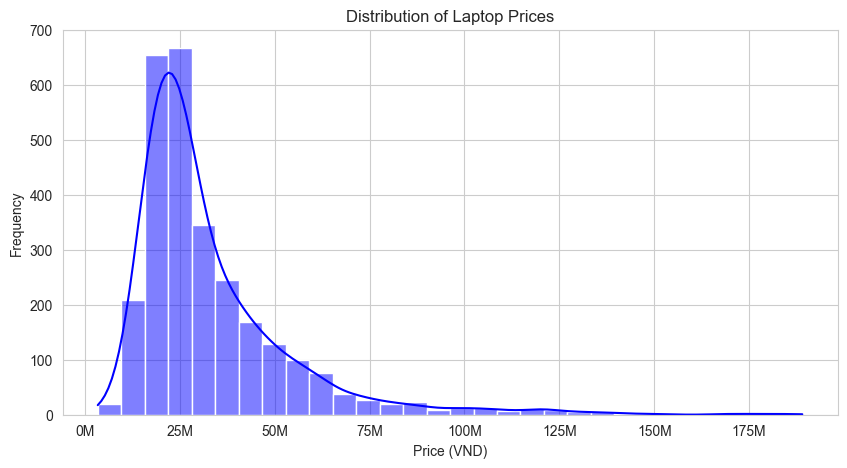

In [4]:
target = 'price'

plt.figure(figsize=(10, 5))
sns.histplot(df[target], bins=30, kde=True, color='blue')
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price (VND)')
plt.ylabel('Frequency')

# Format X-axis to show millions clearly (e.g., 20M instead of 20000000)
formatter = plt.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
plt.gca().xaxis.set_major_formatter(formatter)
plt.show()

### Step 4: Encode Categorical Features
Machine learning algorithms only understand numbers. We convert True/False values to 1/0. For text categories (like CPU Brands: Intel, AMD), we use One-Hot Encoding to turn them into multiple columns of 1s and 0s. 
*(We use `drop_first=True` to prevent the Dummy Variable Trap).*

In [5]:
# Convert boolean to integer (True/False -> 1/0)
if 'is_ai' in df.columns:
    df['is_ai'] = df['is_ai'].astype(int)

# One-Hot Encoding for text categories (Brand, CPU Family, GPU Model, etc.)
# drop_first=True prevents the "Dummy Variable Trap" (Perfect Multicollinearity)
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (2797, 57)


### Step 5: Train / Test Split
To evaluate our model fairly, we split the data. We use 80% of the laptops to "train" (teach) the model, and keep 20% hidden as a "test" set to check its final accuracy.

In [6]:
# Separate Features (X) and Target (y)
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Split into Training Set (80%) and Testing Set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train Set Samples: {X_train.shape[0]}")
print(f"Test Set Samples: {X_test.shape[0]}")

Train Set Samples: 2237
Test Set Samples: 560


### Step 6: Baseline Model (Linear Regression)
We first train a simple Linear Regression model. It assumes prices increase in a straight line as specs get better. 
**Result:** It achieves an $R^2$ score of ~69%, meaning it is okay, but not highly accurate.

In [7]:
# Train a simple Linear Regression model as our baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("--- Baseline Linear Regression ---")
print(f"R² Score: {r2_lr:.4f}")
print(f"MAE:      {mae_lr:,.0f} VND")

--- Baseline Linear Regression ---
R² Score: 0.6932
MAE:      6,842,803 VND


### Step 7: Main Model (Random Forest Regression)
Next, we train a Random Forest model. This model handles complex, non-linear relationships much better (e.g., the price jump from an i5 to an i7 processor is not always a straight line). 
**Result:** It achieves an $R^2$ score of ~88% and a much lower error rate, making it an excellent predictive tool.

In [8]:
# Train a Random Forest Model 
# RF handles non-linear relationships much better than Linear Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("--- Random Forest Regression ---")
print(f"R² Score: {r2_rf:.4f}")
print(f"MAE:      {mae_rf:,.0f} VND")
print(f"RMSE:     {rmse_rf:,.0f} VND")

--- Random Forest Regression ---
R² Score: 0.8838
MAE:      4,210,170 VND
RMSE:     7,293,405 VND


### Step 8: Evaluate Predictions Visually
We plot the Actual Prices against the model's Predicted Prices. The closer the dots are to the red dashed line (Perfect Fit), the more accurate our model is.

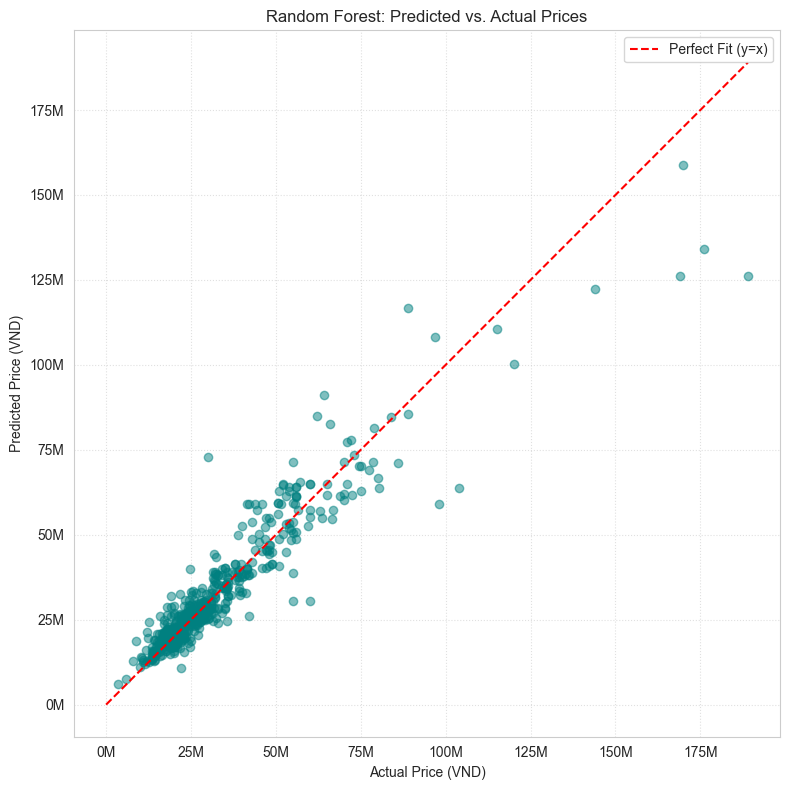

In [9]:
# Visualize how well our Random Forest model predicted the prices
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='teal')

# Draw the perfect prediction line (y = x)
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Fit (y=x)')

plt.title('Random Forest: Predicted vs. Actual Prices')
plt.xlabel('Actual Price (VND)')
plt.ylabel('Predicted Price (VND)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Format axes to millions
formatter = plt.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### Step 9: Feature Importance 
Finally, we ask the Random Forest model which hardware specs influence the price the most. 
**Result:** As expected, Battery capacity, Weight, Storage, and RAM are the heaviest drivers of a laptop's market price.

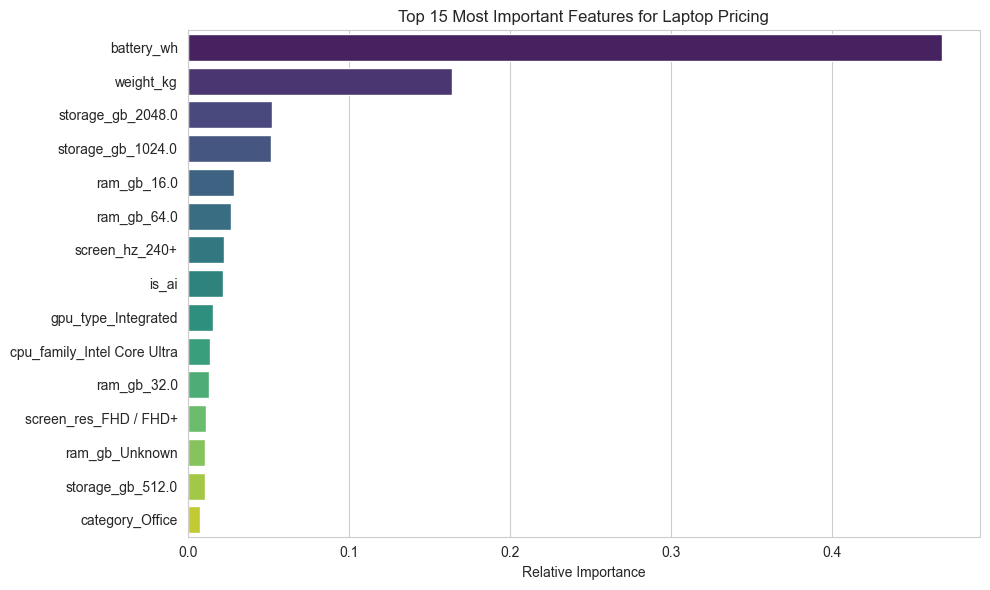

In [10]:
# Extract feature importances from the Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), 
            palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features for Laptop Pricing')
plt.xlabel('Relative Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Insight: Features at the top (likely GPU Model, CPU Family, RAM) dictate the price the most.